In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../')

from minilearn.classifiers import KMeans as MiniKMeans

from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#load saved data
train_df = pd.read_csv('../data/train_features.csv')
test_df = pd.read_csv('../data/test_features.csv')

#seperate featuer and labels
feature_col = [col for col in train_df.columns if col != 'emotion']

X_train = train_df[feature_col].values
y_train = train_df['emotion'].values

X_test = test_df[feature_col].values
y_test = test_df['emotion'].values

#fix featul label space issue
y_train = np.array([label.strip() for label in y_train])
y_test = np.array([label.strip() for label in y_test])

#combine train and test for cross validation.
X_all = np.concatenate([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

print(f"Full dataset: {X_all.shape}")
print(f"Classes {np.unique(y_all)}")

Full dataset: (2452, 112)
Classes ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [5]:
#train minilearn kmeans 
print("Training MiniLearn KMeans")
mini_kmeans = MiniKMeans(n_clusters=8, max_iterations=300, random_state=42)
mini_labels = mini_kmeans.fit_predict(X_all)

#evalute with ARI and NMI
mini_ari = adjusted_rand_score(y_all, mini_labels)
mini_nmi = normalized_mutual_info_score(y_all, mini_labels)

print(f"MiniLearn Kmeans ARI {mini_ari:.4f}")
print(f"MiniLearn KMeans NMI: {mini_nmi:.4f}")


Training MiniLearn KMeans
Converged at iteration 24
MiniLearn Kmeans ARI 0.0550
MiniLearn KMeans NMI: 0.1140


In [7]:
#Sklearn KMeans
print("Training Sklearn KMeans")
sklearn_kmeans = SklearnKMeans(n_clusters=8, random_state=42, n_init=10)
sklearn_labels = sklearn_kmeans.fit_predict(X_all)

sklearn_ari = adjusted_rand_score(y_all, sklearn_labels)
sklearn_nmi = normalized_mutual_info_score(y_all, sklearn_labels)

print(f"Sklearn Kmean ARI: {sklearn_ari:.4f}")
print(f"Sklearn KMeans NMI: {sklearn_nmi:.4f}")

#compare
print("Kmeans comparison")
print(f"{'Model':<20} {'ARI':<10} {'NMI':<10}")
print(f"{'Minilearn KMeans':<20} {mini_ari:<10.4f} {mini_nmi:<10.4f}")
print(f"{'sklearn KMeans':<20} {sklearn_ari:<10.4f} {sklearn_nmi:<10.4f}")


Training Sklearn KMeans
Sklearn Kmean ARI: 0.0571
Sklearn KMeans NMI: 0.1169
Kmeans comparison
Model                ARI        NMI       
Minilearn KMeans     0.0550     0.1140    
sklearn KMeans       0.0571     0.1169    


Explained variance Ratio: [0.18239717 0.09287213]
Total Vaciance explained: 0.2753


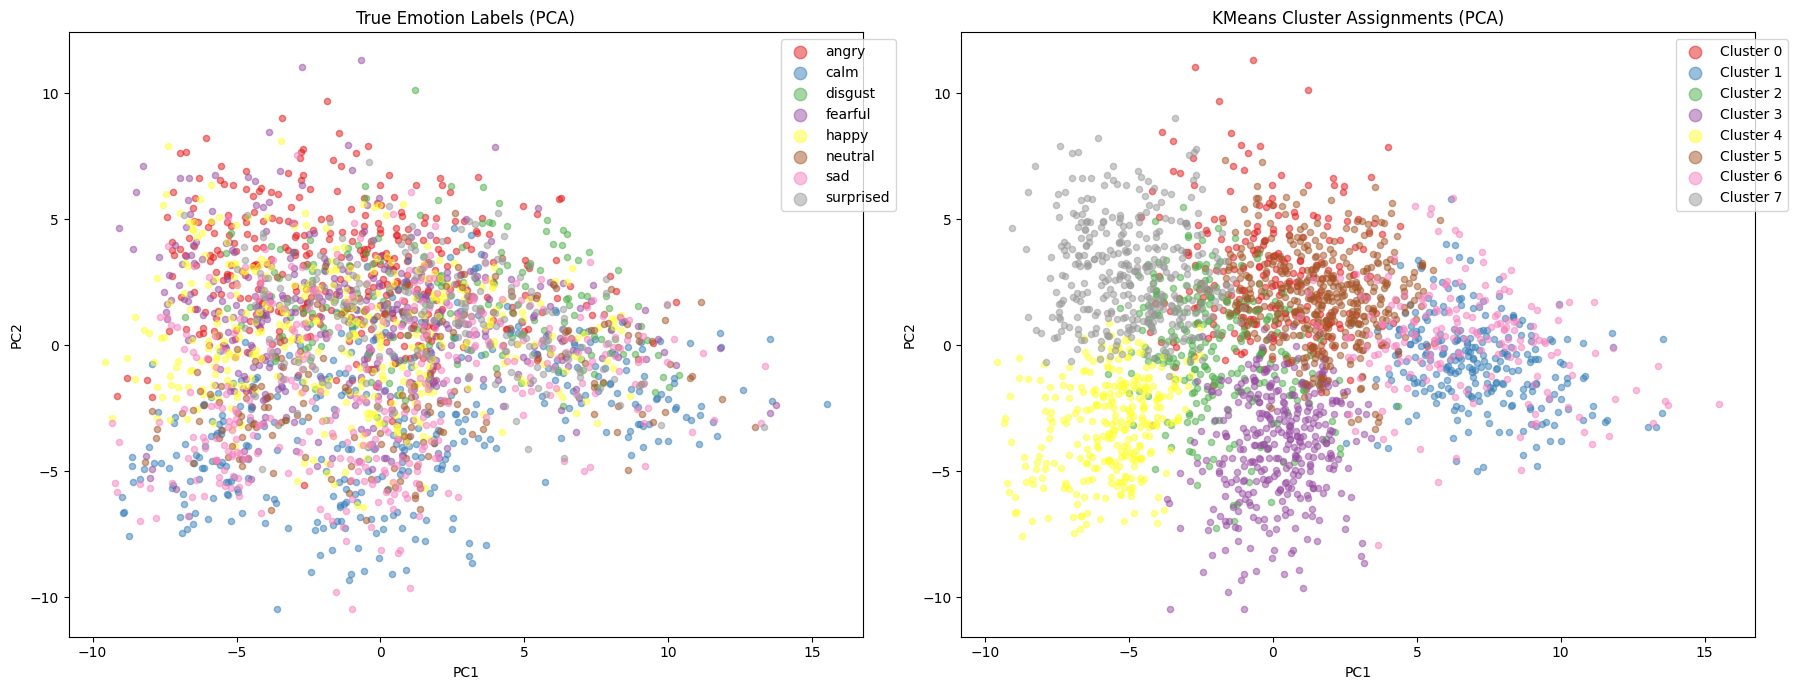

In [9]:
#reduce to 2d using pca for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all)

print(f"Explained variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Vaciance explained: {sum(pca.explained_variance_ratio_):.4f}")

#plot clusters vs true lables 
fig, axes = plt.subplots(1,2,figsize=(18,7))

emotions = np.unique(y_all)
colors = plt.cm.Set1(np.linspace(0,1,8))

for idx, emotion in enumerate(emotions):
    mask = y_all ==emotion
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1], c=[colors[idx]], label=emotion, alpha=0.5, s=20)
axes[0].set_title("True Emotion Labels (PCA)")
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2, bbox_to_anchor=(1.05,1))

#Kmean cluster assignmetns
for k in range(8):
    mask = sklearn_labels == k
    axes[1].scatter(X_pca[mask,0], X_pca[mask,1], c=[colors[k]], label=f"Cluster {k}", alpha=0.5, s=20)
axes[1].set_title("KMeans Cluster Assignments (PCA)")
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=2, bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()


In [10]:
#Hierarchical Clustering Experiement
hierarchical = AgglomerativeClustering(n_clusters=8)
hier_labels = hierarchical.fit_predict(X_all)

hier_ari = adjusted_rand_score(y_all, hier_labels)
hier_nmi = normalized_mutual_info_score(y_all, hier_labels)

print(f"Hierarchical Cluster ARI: {hier_ari:.4f}")
print(f"hierarchical Clustering NMI: {hier_nmi:.4f}")

print("Clustering Comparison")
print(f"{'Model':<25} {'ARI':<10} {'NMI':<10}")
print(f"{'MiniLearn KMeans':<25} {mini_ari:<10.4f} {mini_nmi:<10.4f}")
print(f"{'Sklearn KMeans':<25} {sklearn_ari:<10.4f} {sklearn_nmi:<10.4f}")
print(f"{'Hierarchical':<25} {hier_ari:<10.4f} {hier_nmi:<10.4f}")


Hierarchical Cluster ARI: 0.0295
hierarchical Clustering NMI: 0.0760
Clustering Comparison
Model                     ARI        NMI       
MiniLearn KMeans          0.0550     0.1140    
Sklearn KMeans            0.0571     0.1169    
Hierarchical              0.0295     0.0760    


Analysis